<a href="https://colab.research.google.com/github/njadux/Computer-Vision/blob/Image-Classification/CNN_and_Pooling_Fashion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Description:

This project aims to build and train a deep neural network (DNN) to classify images of clothing items into 10 different categories. The project utilizes the Fashion MNIST dataset, which contains 70,000 grayscale images of clothing articles at a resolution of 28x28 pixels. The model is built using TensorFlow and Keras and incorporates convolutional layers, pooling layers, and dense layers to achieve accurate classification.



1.   Load data
2.   make class array with all categeories
3.   explore data shape and lens
4.   print training_image in numerical format and its categeory
5.   change the data between 0 and 1 by dividing it by 255
6.   train model with 10 clusters
7.   compile and fit model
8.   evaluate and make predict


# Classify images of clothing

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

**Import the Fashion MNIST dataset**

- This guide uses the Fashion MNIST dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels)

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels),(test_images, test_labels) = fashion_mnist.load_data()

The images are 28x28 NumPy arrays, with pixel values ranging from 0 to 255. The labels are an array of integers, ranging from 0 to 9. These correspond to the class of clothing the image represents:

Label	Class
- 0	T-shirt/top
- 1	Trouser
- 2	Pullover
- 3	Dress
- 4	Coat
- 5	Sandal
- 6	Shirt
- 7	Sneaker
- 8	Bag
- 9	Ankle boot


In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Explore the data

In [ ]:
training_images.shape

(60000, 28, 28)

In [ ]:
len(test_images)

10000

In [ ]:
test_images.shape

(10000, 28, 28)

In [ ]:
len(test_labels)

10000

In [ ]:
len(training_images)

60000

In [ ]:
training_labels.shape

(60000,)

In [ ]:
len(training_labels)

60000

In [ ]:
test_labels.shape

(10000,)

In [ ]:
# choosing img index between 0 - 5999
index = 1234

# setting num of rows
np.set_printoptions(linewidth= 320)
print(f"labeled : {training_labels[index]}")
print(f"image : {training_images[index]}")

labeled : 8
image : [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0  42  41  52  52  58  28   0  17   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 107 156 165 187 144 148 204 186 117 122  44  15  12  14  20  29  36  51  50  49  42  52  73  98 115 133  42]
 [ 28 167 163 144 134 126 110  99  99 117 128 150 165 159 156 161 161 150 149 149 158 170 182 170 182 187 209 161]
 [ 24 150 139 142 144 140 148 163 166 171 166 164 163 172 17

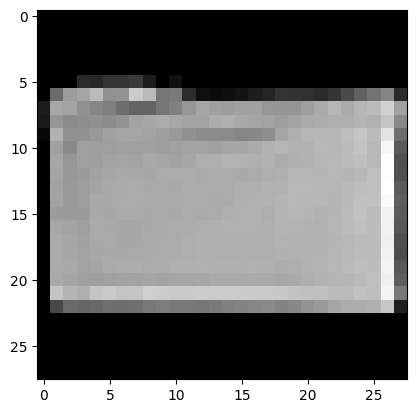

In [ ]:
plt.imshow(training_images[index], cmap = 'gray')
plt.show()

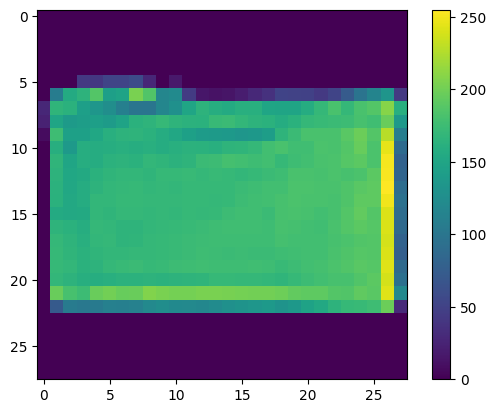

In [ ]:
plt.imshow(training_images[index])
plt.colorbar()
plt.show()

In [ ]:
index = 3000
np.set_printoptions(linewidth= 320)

# print the category from labels array
print(f"labels : {training_labels[index]}")

#print image in numerical array
print(f"image : {training_images[index]}")

labels : 6
image : [[  0   0   0   0   0   0   0   0   1   1   0   0 120 131  91 147  30   0   0   1   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1   3   0   0   0   0 251 199 172 195 152   0   0   0   0   3   1   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  43 124 193 166 239 255 216 172 228 126  61   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  96 167 155 159 171 178 211 215 210 196 189 158 164 159 108   0   0   0   0   0   0]
 [  0   0   0   0   0   0  83 157 131 117 120 148 148 145 178 159 174 160 123 132 142 172  38   0   0   0   0   0]
 [  0   0   0   0   0   0 159 128 118 120 122 112  93 124 161 109 128 128 129 146 138 167 122   0   0   0   0   0]
 [  0   0   0   0   0   0 171 135 120 114 118 119 107 125 123 117 124 124 119 145 147 166 148   0   0   0   0   0]
 [  0   0   0   0   0   4 171 138 126 120 117 118 102 122 145 111 120 122 120 152 154 155 170   0   0   0   0   0]
 [  0   0   0   0   0  31 170 129 138 125 113 106 103 118 137

In [ ]:
# Train the model
# change the data between 0 and 1 by dividing it by 255

training_images = training_images / 255.0
test_images =  test_images / 255.0

# Define Model

The filters start with a random known good filters
The pooling Layer:
- takes the maximum num after applying the filter

add the convolutional layer and pooling layer so the network can learn another set of conv (filters) on the top of the existing one, and the pool will reduce the size again

> Input(shape=(28, 28, 1)):

Functional API: This syntax is typically used when building models using the functional API.

In [ ]:
# added convolutions
model = tf.keras.Sequential([
    # the adding 1 eans that we are use=ing a single byte color depth (gray-scale)
    tf.keras.Input(shape = (28, 28, 1)),

    # ask keras to generate 64 filter, which is 3 by 3 (its size), the shape is as before
    # their act. is relu, means the neg. values will be thrown away
    tf.keras.layers.Conv2D(16, (3,3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(16, (3,3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # normal nn layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation = 'relu'),
    tf.keras.layers.Dense(10, activation= 'softmax')
])

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
model.fit(
    training_images,
    training_labels,
    epochs = 10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7809 - loss: 0.6085
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8800 - loss: 0.3217
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8978 - loss: 0.2710
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9092 - loss: 0.2415
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9217 - loss: 0.2120
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9258 - loss: 0.1935
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9357 - loss: 0.1729
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9398 - loss: 0.1558
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9499 - loss: 0.1357
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9532 - loss: 0.1243


Summary() method allows you to inspect model layers and see the journeyo of the image through the Convolutions

in the output column the shape is 26 x 26
because the pixel in the top left won't work with the filter because it doesn't have neighbors above it or to its  left, so the first pixel will be able to do this is :

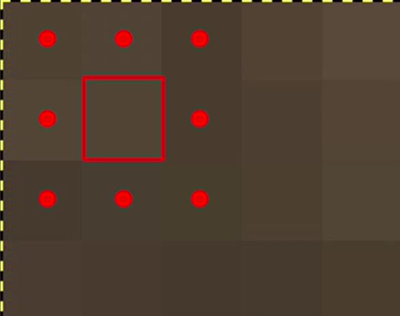

Because this pixel has neighbors that a filter with 3 by 3 needs
we've removed one pixel on x and y.

now our output gets reduced from 26 by 26 to 13 by 13. The convolutions will then operate on that, and of course we lose the one pixel margin as before. So we're down to 11 by 11, add another 2 by 2 max pooling to halve this rounding down, and we're now down to 5 by 5 images. So now our dense neural network is the same as before, but it's being fed with 5 by 5 images instead of 28 by 28 ones

 Flatten that out and you have 25 pixels times 64, which is 1600. So you can see that the new flattened layer has 1600 elements in it, as opposed to the 784 that you had previously. This number is impacted by the parameters that you set when defining the convolutional 2d layers.

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1024)                │         410,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │          10,250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,270,064 (4.84 MB)

 Trainable params: 423,354 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 846,710 (3.23 MB)

In [ ]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9045 - loss: 0.3170


[0.30983468890190125, 0.9049000144004822]

In [ ]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9045 - loss: 0.3170


In [ ]:
print(f"Test Acuuracy: {test_accuracy}")
print(f"Test loss: {test_loss} ")

Test Acuuracy: 0.9049000144004822
Test loss: 0.30983468890190125 


In [ ]:
prediction = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
predicted_labels = np.argmax(prediction, axis=1)

In [ ]:
print(predicted_labels)

[9 2 1 ... 8 1 5]


Visualize all dresses in the first 100 images


- The model takes a test image as input and predicts a label (e.g., the digit in the image).
- The predicted label is compared with the test label to see if the prediction is correct.

In [ ]:
print(f" first 100 images in test labels are : {test_labels[:100]}")
print(f"Dresses in them are: {[i for i in range(100) if test_labels[i] == 3]}")

 first 100 images in test labels are : [9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1 4 6 0 9 3 8 8 3 3 8 0 7 5 7 9 6 1 3 7 6 7 2 1 2 2 4 4 5 8 2 2 8 4 8 0 7 7 8 5 1 1 2 3 9 8 7 0 2 6 2 3 1 2 8 4 1 8 5 9 5 0 3 2 0 6 5 3 6 7 1 8 0 1 4 2]
Dresses in them are: [13, 29, 32, 33, 42, 67, 75, 86, 91]


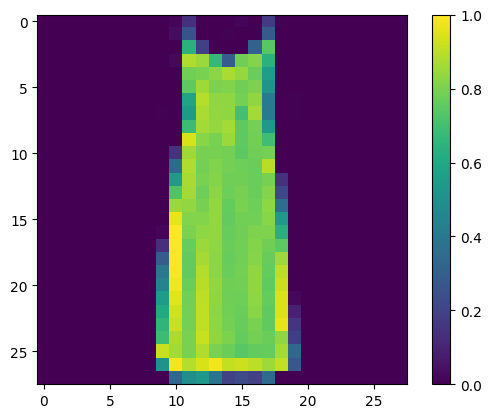

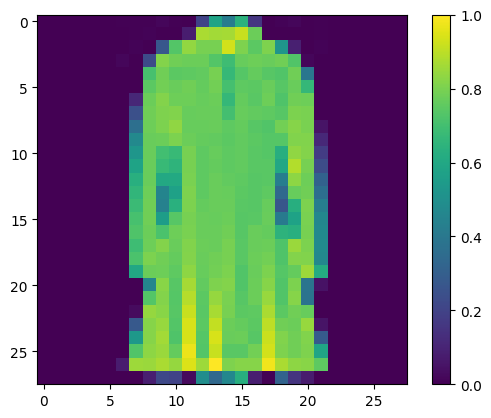

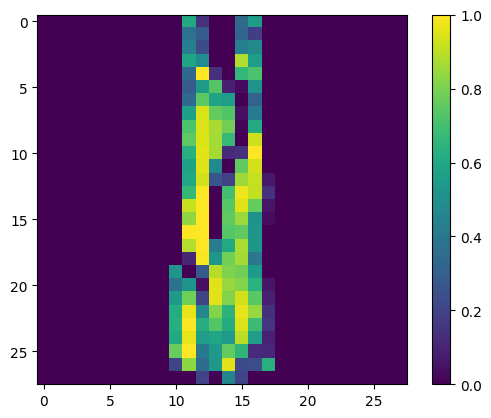

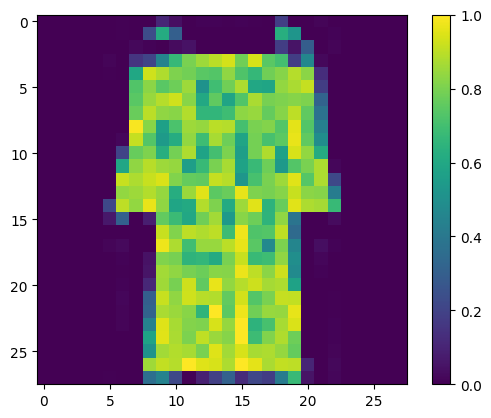

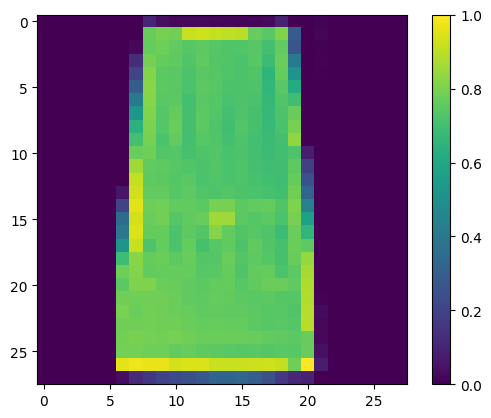

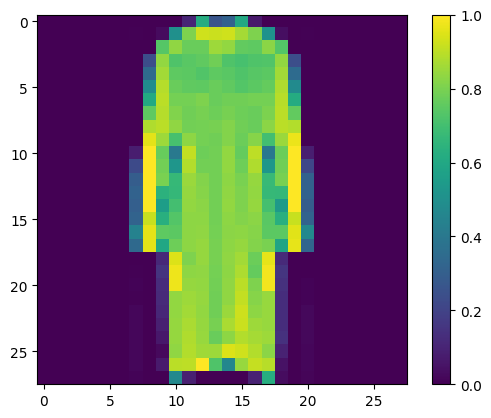

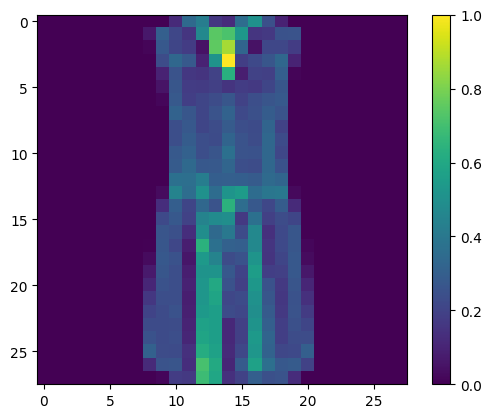

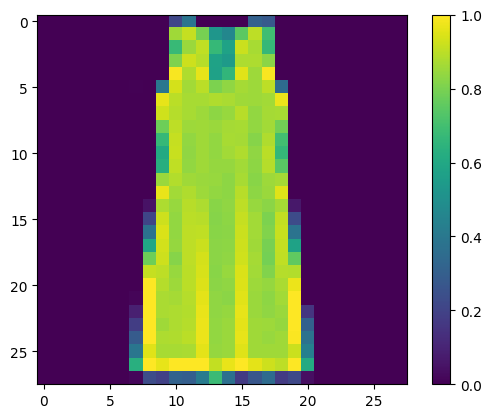

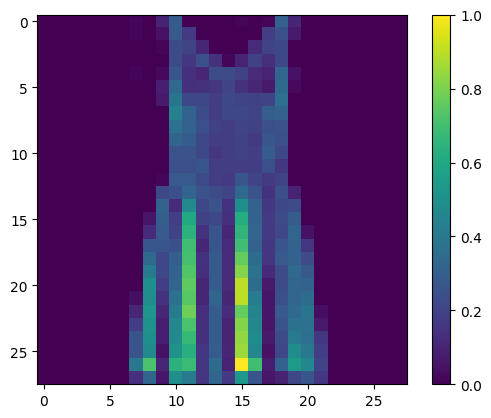

In [ ]:
for i in range(100):
    if test_labels[i] == 3:
     plt.imshow(test_images[i])
     plt.colorbar()
     plt.show()

Label: 3, Class: Dress


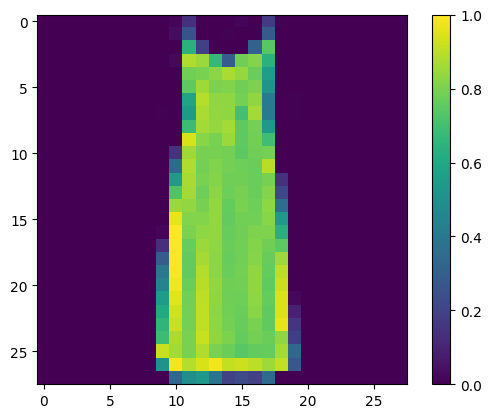

Label: 3, Class: Dress


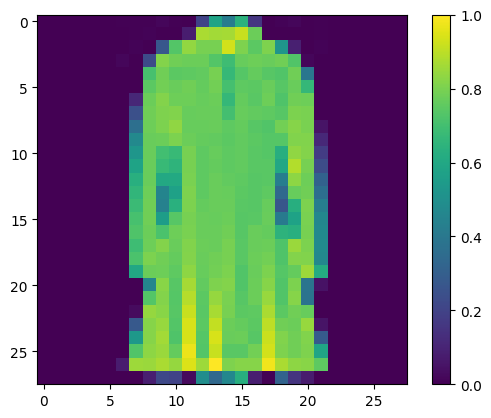

Label: 3, Class: Dress


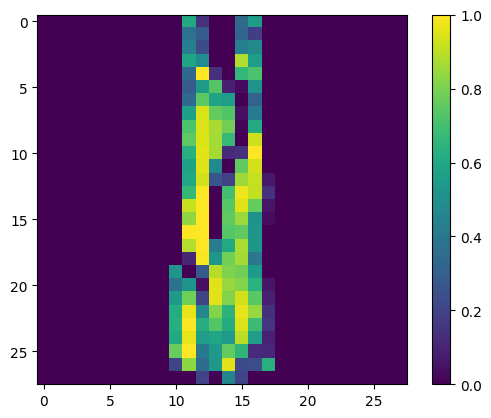

Label: 3, Class: Dress


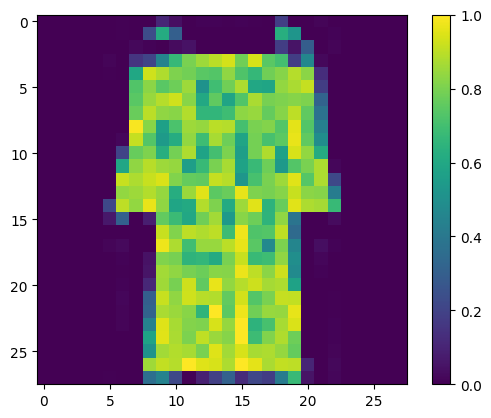

Label: 3, Class: Dress


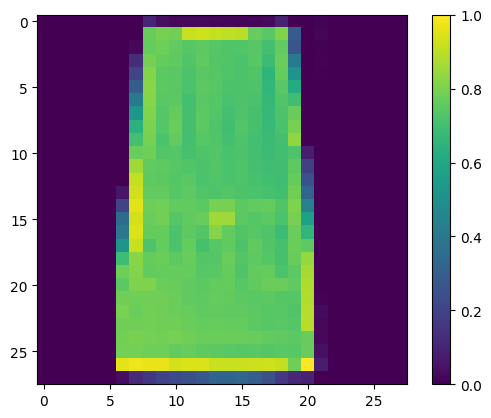

Label: 3, Class: Dress


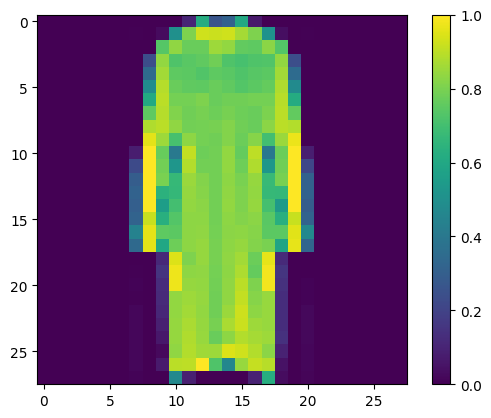

Label: 3, Class: Dress


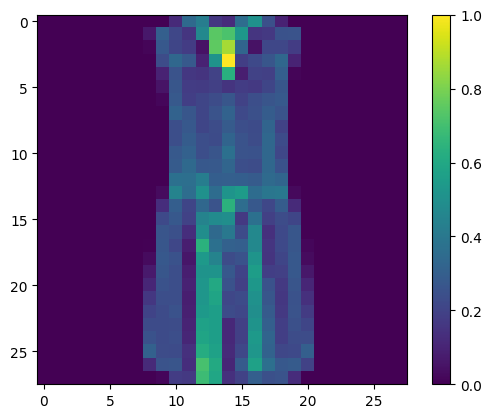

Label: 3, Class: Dress


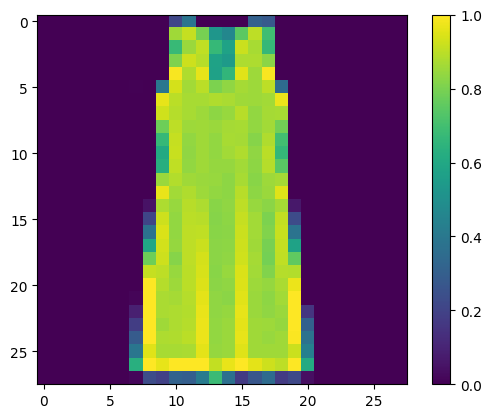

Label: 3, Class: Dress


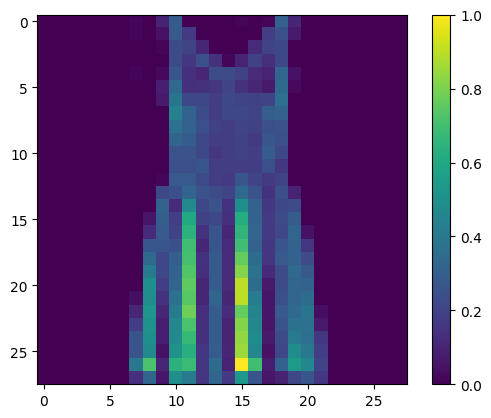

In [ ]:
for i in range(100):
       if test_labels[i] == 3:
           print(f"Label: {test_labels[i]}, Class: {class_names[test_labels[i]]}")
           plt.imshow(test_images[i])
           plt.colorbar()
           plt.show()

Purpose: Extracts the output tensors of the layers specified in layers_to_visualize.
- model.layers: A list of all layers in the model.
- layer.output: Refers to the output tensor of a given layer.

Purpose: Creates a new model, activation_model, that takes the same inputs as the original model (model) but :
- outputs the activations of only the selected layers (layer_outputs).

Purpose: Creates a figure (fig) and a grid of subplots (axes) for displaying the activation maps.
> (num of rows,len(layer_outputs))
- Number of rows (to visualize three images: FIRST_IMAGE, SECOND_IMAGE, THIRD_IMAGE).
- len(layer_outputs): Number of columns (equal to the number of layers being visualized).

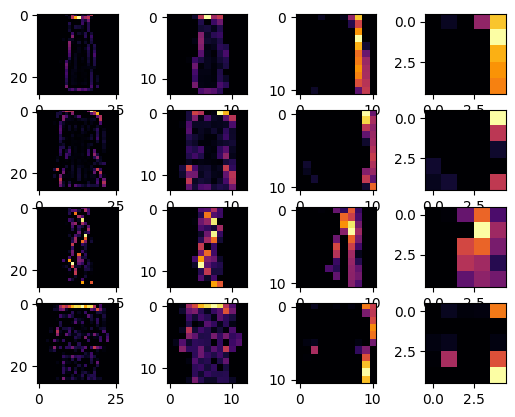

In [ ]:
first_img = 13
second_img = 29
third_img = 32
fourth_img = 33

Convolution_num = 1
layers_to_visualize = [tf.keras.layers.Conv2D, tf.keras.layers.MaxPooling2D]
layers_output = [layer.output for layer in model.layers if type(layer) in layers_to_visualize]
activation_model = tf.keras.models.Model(inputs= model.inputs, outputs = layers_output)

fig, axes = plt.subplots(4,len(layers_output))

for x in range(len(layers_output)):
  # batch size is set to 1 to indicate that only one image is being passed through the network.
  # verbose: Suppresses unnecessary output during prediction.
  f1 = activation_model.predict(test_images[first_img].reshape(1,28,28,1),verbose = False)[x]
  #  at position (0, x), sets the color map to "inferno"
  axes[0,x].imshow(f1[0, :, :, Convolution_num], cmap = 'inferno')
  axes[0,x].grid(False)

  f2 = activation_model.predict(test_images[second_img].reshape(1,28,28,1), verbose = False)[x]
  axes[1,x].imshow(f2[0, :, :, Convolution_num], cmap = 'inferno')
  axes[1,x].grid(False)

  f3 = activation_model.predict(test_images[third_img].reshape(1, 28, 28, 1), verbose = False)[x]
  axes[2,x].imshow(f3[0, :, :, Convolution_num], cmap = 'inferno')

  f4 = activation_model.predict(test_images[fourth_img].reshape(1,28, 28,1), verbose = False)[x]
  axes[3,x].imshow(f4[0, :, :, Convolution_num], cmap = 'inferno')

# Exploring Convolutions¶

In [ ]:
# load image, ascent image from Scipy
from scipy.datasets import ascent
ascent_image = ascent()

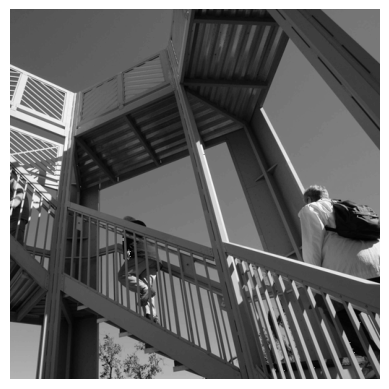

In [ ]:
plt.grid(False)
plt.gray()
plt.axis('off')
plt.imshow(ascent_image)
plt.show()

In [ ]:
# image is stored in numpy array, we can create the transformed img by coping it
# copy image to numpy array

img_transformed = np.copy(ascent_image)

# get dimensions of the image
width = img_transformed.shape[0]
height = img_transformed.shape[1]

In [ ]:
print(f"The image has shape: {width, height}")

The image has shape: (512, 512)


 If all the digits in the filter don't add up to 0 or 1, you
- should probably do a weight to get it to do so
> so, for example, if your weights are 1,1,1 1,2,1 1,1,1
> They add up to 10, so you would set a weight of .1 if you want to normalize them

In [ ]:
# create filters as 3x3
filter = [[0, 1, 0], [1, -4, 1], [0, 1, 0]]
weight = 1

Create a convolution. You will iterate over the image, leaving a 1 pixel margin, and multiplying each of the neighbors of the current pixel by the value defined in the filter (i.e. the current pixel's neighbor above it and to the left will be multiplied by the top left item in the filter, etc.)

> then multiply the result by the weight, and then ensure the result is in the range 0-255.

In [ ]:
for n in range(1, width-1):
  for j in range(1, height-1):
    convolution = 0.0
    convolution = convolution + (ascent_image[n-1, j-1] * filter[0][0])
    convolution = convolution + (ascent_image[n, j]     * filter[0][1])
    convolution = convolution + (ascent_image[n+1, j+1] * filter[0][2])

    convolution = convolution + (ascent_image[n-1, j-1] * filter[1][0])
    convolution = convolution + (ascent_image[n, j]     * filter[1][1])
    convolution = convolution + (ascent_image[n+1, j+1] * filter[1][2])

    convolution = convolution + (ascent_image[n-1, j-1] * filter[2][0])
    convolution = convolution + (ascent_image[n,j]      * filter[2][1])
    convolution = convolution + (ascent_image[n+1, j+1] * filter[2][2])

    # multiply by the weight
    convolution = convolution * weight

    # check the boundries of the pixel values
    if (convolution < 0):
      convolution = 0
    if (convolution > 255):
      convolution = 255

    # load it into transformed image
    img_transformed[n, j] = convolution

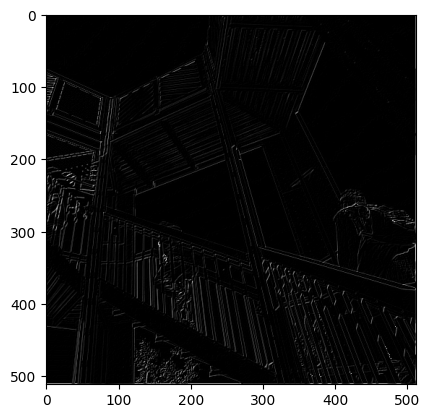

In [ ]:
plt.gray()
plt.grid(False)
plt.imshow(img_transformed)
plt.show()

In [ ]:
# assign dimensions half the size of the original image
new_width  = int(width / 2)
new_height = int(height / 2)

# create blank image with reduced dimensions
blank = np.zeros((new_width, new_height))

In [ ]:
# iterate over the image
for n in range (0, width, 2):
  for j in range (0, height, 2):

    # store all pixel values in pool (2,2)
    pixels = []
    pixels.append(img_transformed[n, j])
    pixels.append(img_transformed[n+1, j])
    pixels.append(img_transformed[n, j+1])
    pixels.append(img_transformed[n+1, j+1])

    # get only the largest value and assign it to the reduced image
    newImage[int(n / 2), int(j / 2)] = max(pixels)

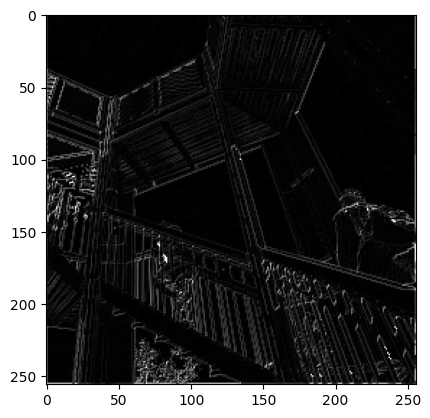

In [ ]:
plt.imshow(newImage)
plt.grid(False)
plt.gray()
plt.show()